# Step 1 – Canonical single crack tip (Mode I & II) in isotropic ice

In this notebook we:

- Consider an infinite isotropic plate with a straight crack along the negative x-axis.
- Use classical LEFM / Williams expansions to get the **near-tip fields** for Mode I and Mode II.
- Interpret the singular exponent as a simple **eigenvalue** \( $\lambda = 1/2$ \).
- Treat the angular dependence of the fields as **eigenforms**.
- Compute **energy release rates** \($G_I, G_{II}$\) as scalar amplitudes.
- Show how the radial scaling fits into a minimal **Recho-style Hamiltonian** viewpoint.

We do **not** yet construct a graph; that comes once we have multiple crack tips and interactions.


## 1. Setup: material properties, geometry, and canonical loading

We assume:

- Isotropic, homogeneous ice with Young’s modulus $E$ and Poisson’s ratio $\nu$.
- Plane strain conditions.
- A semi-infinite straight crack along the negative x-axis.
- Polar coordinates $(r,\theta)$ centered at the crack tip, with $\theta = 0$ along the positive x-axis and crack faces at $\theta = \pm\pi$.

We introduce canonical Mode I and Mode II stress intensity factors:
- $K_I$ for opening (Mode I),
- $K_{II}$ for in-plane shear (Mode II).

For this step, we take $K_I = K_{II} = 1$ as canonical values and later scale to physical loadings.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Material properties for (approximate) isotropic ice ---
E = 9e9          # Young's modulus [Pa] (example ~9 GPa)
nu = 0.30        # Poisson's ratio

# Plane strain effective modulus
E_eff = E / (1.0 - nu**2)

# Shear modulus
mu = E / (2.0 * (1.0 + nu))

# kappa parameter (plane strain) for Williams solution (not sure about this, check or read)
kappa = 3.0 - 4.0 * nu   # for plane strain

print(f"E = {E:.3e} Pa, nu = {nu}, E_eff = {E_eff:.3e} Pa, mu = {mu:.3e} Pa, kappa = {kappa:.3f}")


E = 9.000e+09 Pa, nu = 0.3, E_eff = 9.890e+09 Pa, mu = 3.462e+09 Pa, kappa = 1.800


We also define:

- Canonical stress intensity factors $K_I$ and $K_{II}$,
- A small sampling radius $r_0$ near the tip,
- An angular grid $\theta \in [-\pi, \pi]$.

We will use $r = r_0$ as a **sampling circle** around the crack tip; the radial dependence is fixed, and the angular dependence will be treated as the eigenform.


In [3]:
# Canonical stress intensity factors
K_I = 1.0   # Mode I canonical SIF
K_II = 1.0  # Mode II canonical SIF

# Angular grid for sampling eigenforms
n_theta = 400
theta = np.linspace(-np.pi, np.pi, n_theta)

# Sampling radius
r0 = 1.0   # arbitrary units; scaling is captured by K and r^±1/2

# Singularity exponent (eigenvalue in the Williams/Recho sense)
lambda_sing = 0.5


## 2. Mode I canonical near-tip fields (Williams / LEFM)

Classical LEFM gives the near-tip stress and displacement fields in terms of
$K_I$, $r$, and $\theta$. For Mode I in an isotropic infinite plate, the
stress field in polar coordinates $(r,\theta)$ is (plane strain):

$$
\begin{aligned}
\sigma_{rr}^{(I)}(r,\theta)
&= \frac{K_I}{\sqrt{2\pi r}} \cos\frac{\theta}{2}
\left( 1 - \sin\frac{\theta}{2} \sin\frac{3\theta}{2} \right), \\
\sigma_{\theta\theta}^{(I)}(r,\theta)
&= \frac{K_I}{\sqrt{2\pi r}} \cos\frac{\theta}{2}
\left( 1 + \sin\frac{\theta}{2} \sin\frac{3\theta}{2} \right), \\
\sigma_{r\theta}^{(I)}(r,\theta)
&= \frac{K_I}{\sqrt{2\pi r}} \sin\frac{\theta}{2}
\cos\frac{\theta}{2} \cos\frac{3\theta}{2}.
\end{aligned}
$$

The displacements in polar coordinates can be written as

$$
\begin{aligned}
u_r^{(I)}(r,\theta)
&= \frac{K_I}{2E}
\sqrt{\frac{r}{2\pi}}
(1+\nu)\left[
(2\kappa - 1) \cos\frac{\theta}{2}
- \cos\frac{3\theta}{2}
\right], \\
u_\theta^{(I)}(r,\theta)
&= \frac{K_I}{2E}
\sqrt{\frac{r}{2\pi}}
(1+\nu)\left[
-(2\kappa - 1) \sin\frac{\theta}{2}
+ \sin\frac{3\theta}{2}
\right].
\end{aligned}
$$

The key point for our eigen-interpretation is:

- **Stresses** scale like $ \sigma \sim r^{-1/2}$.
- **Displacements** scale like  $u \sim r^{+1/2}$.

This corresponds to the singular exponent $\lambda = 1/2$ in the separated form
$\text{field}(r,\theta) \sim r^{\lambda - 1} \psi(\theta)$.


In [ ]:
def mode_I_stresses_polar(r, theta, K_I):
    """
    Mode I crack-tip stresses (sigma_rr, sigma_rtheta, sigma_thetatheta)
    in polar coordinates for an infinite isotropic plate (plane strain).
    """
    pref = K_I / np.sqrt(2.0 * np.pi * r)
    ct2 = np.cos(theta / 2.0)
    st2 = np.sin(theta / 2.0)
    c3t2 = np.cos(3.0 * theta / 2.0)
    s3t2 = np.sin(3.0 * theta / 2.0)

    sigma_rr = pref * ct2 * (1.0 - st2 * s3t2)
    sigma_tt = pref * ct2 * (1.0 + st2 * s3t2)
    sigma_rt = pref * st2 * ct2 * c3t2
    return sigma_rr, sigma_rt, sigma_tt


def mode_I_displacements_polar(r, theta, K_I, E, nu, kappa):
    """
    Mode I crack-tip displacements (u_r, u_theta) in polar coordinates
    (plane strain) using the standard LEFM expressions.
    """
    pref = (K_I / (2.0 * E)) * np.sqrt(r / (2.0 * np.pi)) * (1.0 + nu)
    ct2 = np.cos(theta / 2.0)
    st2 = np.sin(theta / 2.0)
    c3t2 = np.cos(3.0 * theta / 2.0)
    s3t2 = np.sin(3.0 * theta / 2.0)

    u_r = pref * ((2.0 * kappa - 1.0) * ct2 - c3t2)
    u_t = pref * (-(2.0 * kappa - 1.0) * st2 + s3t2)
    return u_r, u_t


# Evaluate Mode I fields at r = r0
sigma_rr_I, sigma_rt_I, sigma_tt_I = mode_I_stresses_polar(r0, theta, K_I)
u_r_I, u_t_I = mode_I_displacements_polar(r0, theta, K_I, E, nu, kappa)


# check outputs
sigma_rr_I.shape, u_r_I.shape


((400,), (400,))

## 3. Mode II canonical near-tip fields

For Mode II (in-plane shear sliding), the stress field in polar coordinates $(r,\theta)$ can be written as:  

$$
\begin{aligned}
\sigma_{rr}^{(II)}(r,\theta)
&= \frac{K_{II}}{\sqrt{2\pi r}}
\sin\frac{\theta}{2}\left(1 - 3\sin^2\frac{\theta}{2}\right), \\
\sigma_{\theta\theta}^{(II)}(r,\theta)
&= \frac{K_{II}}{\sqrt{2\pi r}}
\left(-3 \sin\frac{\theta}{2}\cos^2\frac{\theta}{2}\right), \\
\sigma_{r\theta}^{(II)}(r,\theta)
&= \frac{K_{II}}{\sqrt{2\pi r}}
\cos\frac{\theta}{2}\left(1 - 3\sin^2\frac{\theta}{2}\right).
\end{aligned}
$$

The displacements in polar coordinates are (plane strain):

$$
\begin{aligned}
u_r^{(II)}(r,\theta)
&= \frac{K_{II}}{2E}
\sqrt{\frac{r}{2\pi}} (1+\nu)
\left[
-(2\kappa - 1)\sin\frac{\theta}{2}
+ 3\sin\frac{3\theta}{2}
\right], \\
u_\theta^{(II)}(r,\theta)
&= \frac{K_{II}}{2E}
\sqrt{\frac{r}{2\pi}} (1+\nu)
\left[
-(2\kappa + 1)\cos\frac{\theta}{2}
+ 3\cos\frac{3\theta}{2}
\right].
\end{aligned}
$$

Again, near the tip:

- **Stresses** scale like $r^{-1/2}$,
- **Displacements** scale like $r^{+1/2}$,

corresponding to the same eigenvalue $\lambda_{II} = 1/2$ but with different angular eigenforms.


In [5]:
def mode_II_stresses_polar(r, theta, K_II):
    """
    Mode II crack-tip stresses (sigma_rr, sigma_rtheta, sigma_thetatheta)
    in polar coordinates (plane strain).
    """
    pref = K_II / np.sqrt(2.0 * np.pi * r)
    ct2 = np.cos(theta / 2.0)
    st2 = np.sin(theta / 2.0)

    sigma_rr = pref * st2 * (1.0 - 3.0 * st2**2)
    sigma_tt = pref * (-3.0 * st2 * ct2**2)
    sigma_rt = pref * ct2 * (1.0 - 3.0 * st2**2)
    return sigma_rr, sigma_rt, sigma_tt


def mode_II_displacements_polar(r, theta, K_II, E, nu, kappa):
    """
    Mode II crack-tip displacements (u_r, u_theta) in polar coordinates
    (plane strain) using standard LEFM expressions.
    """
    pref = (K_II / (2.0 * E)) * np.sqrt(r / (2.0 * np.pi)) * (1.0 + nu)
    ct2 = np.cos(theta / 2.0)
    st2 = np.sin(theta / 2.0)
    c3t2 = np.cos(3.0 * theta / 2.0)
    s3t2 = np.sin(3.0 * theta / 2.0)

    u_r = pref * (-(2.0 * kappa - 1.0) * st2 + 3.0 * s3t2)
    u_t = pref * (-(2.0 * kappa + 1.0) * ct2 + 3.0 * c3t2)
    return u_r, u_t


# Evaluate Mode II fields at r = r0
sigma_rr_II, sigma_rt_II, sigma_tt_II = mode_II_stresses_polar(r0, theta, K_II)
u_r_II, u_t_II = mode_II_displacements_polar(r0, theta, K_II, E, nu, kappa)

# check outputs
sigma_rr_II.shape, u_r_II.shape


((400,), (400,))

## 4. Eigenforms and state vectors

For each mode (I and II), we can construct a **state vector** at each angle $\theta_k$:

$$
\mathbf{v}^{(m)}(\theta_k) =
\begin{bmatrix}
u_r^{(m)}(\theta_k) \\
u_\theta^{(m)}(\theta_k) \\
\sigma_{rr}^{(m)}(\theta_k) \\
\sigma_{r\theta}^{(m)}(\theta_k)
\end{bmatrix},
\quad m \in \{I, II\}.
$$

We fix $r = r_0$; this factors out the radial dependence, so the set of vectors
$\mathbf{v}^{(m)}(\theta_k)$ as a function of $\theta_k$ represents the **angular eigenform** associated with eigenvalue $\lambda = 1/2$.

We’ll stack these into arrays of shape $(n_\theta, 4)$.


In [6]:
def build_state_vectors(u_r, u_t, sigma_rr, sigma_rt):
    """
    Stack components into state vectors v(theta_k) of length 4.
    Returns an array of shape (n_theta, 4).
    """
    return np.stack([u_r, u_t, sigma_rr, sigma_rt], axis=-1)

v_I_theta = build_state_vectors(u_r_I, u_t_I, sigma_rr_I, sigma_rt_I)
v_II_theta = build_state_vectors(u_r_II, u_t_II, sigma_rr_II, sigma_rt_II)

print("Mode I state vectors shape:", v_I_theta.shape)
print("Mode II state vectors shape:", v_II_theta.shape)


Mode I state vectors shape: (400, 4)
Mode II state vectors shape: (400, 4)


At this stage we can think of:

- **Eigenvalue:**  
  $$ \lambda_I = \lambda_{II} = \frac{1}{2}. $$

- **Eigenforms:** the angular patterns $\theta \mapsto \mathbf{v}^{(m)}(\theta)$.

In a more complete Recho formulation, these eigenforms would come from solving an
eigenvalue problem involving a Hamiltonian operator acting on the state
$\mathbf{v}$; here we are using the known closed-form solution and then
interpreting it as an eigenpair.


## 5. Amplitudes: energy release rates $G_I$ and $G_{II}$

For an isotropic material under plane strain, the energy release rate for Mode I and Mode II are:

$$
G_I = \frac{K_I^2}{E'}, \qquad
G_{II} = \frac{K_{II}^2}{E'},
$$

where

$$
E' = \frac{E}{1-\nu^2}
$$

is the effective modulus in plane strain.

For mixed-mode loading, the total energy release rate would be

$$
G = \frac{K_I^2 + K_{II}^2}{E'}.
$$

Here we just compute the Mode I and Mode II contributions separately and interpret them as **mode amplitudes** for the eigenforms.


In [7]:
def energy_release_rate_mode_I(K_I, E_eff):
    return (K_I**2) / E_eff

def energy_release_rate_mode_II(K_II, E_eff):
    return (K_II**2) / E_eff

G_I = energy_release_rate_mode_I(K_I, E_eff)
G_II = energy_release_rate_mode_II(K_II, E_eff)

print(f"G_I  = {G_I:.3e} J/m^2")
print(f"G_II = {G_II:.3e} J/m^2")


G_I  = 1.011e-10 J/m^2
G_II = 1.011e-10 J/m^2


In later stages (when you build graphs), we could:

- Use $G_I$, $G_{II}$, or some functional of them as **edge weights** between nodes,
- Or encode a **mode mix** parameter like
  $$ \psi = \tan^{-1}\left( \frac{K_{II}}{K_I} \right) $$
  as part of your node/edge features. (not sure how this works but chatGPT says it could be useful)

For this Step 1, it is enough that we have:

- Canonical eigenforms (Mode I and II),
- Canonical amplitudes $G_I, G_{II}$ for given $K_I, K_{II}$.


## 6. Recho-style Hamiltonian viewpoint

Recho’s formulation casts the crack-tip fields into a first-order system in the
**log-radial coordinate**:

- Define $\xi = \ln r$.
- For a separated solution with radial scaling

  $$
  \mathbf{v}(r,\theta) = r^{\lambda - 1} \Psi(\theta),
  $$

  we have

  $$
  \frac{\partial \mathbf{v}}{\partial \xi}
  = \frac{\partial \mathbf{v}}{\partial (\ln r)}
  = (\lambda - 1)\, \mathbf{v}.
  $$

This can be written as a simple “Hamiltonian evolution” in $\xi$:

$$
\frac{d\mathbf{v}}{d\xi} = H_\text{rad} \, \mathbf{v},
$$

with

$$
H_\text{rad} = (\lambda - 1) I.
$$

For the leading singular modes (I and II), we have $\lambda = 1/2$, so

$$
H_\text{rad} = -\frac{1}{2} I.
$$

In the **full Recho Hamiltonian**, $H$ is a non-trivial matrix built from
the stiffness tensor components and geometry, and its eigenvalues/eigenvectors
give you the exponents and eigenforms. Here, for this simple isotropic single
crack case, the radial part reduces to a scalar multiple of the identity.

We can implement this minimal radial evolution as a small function and verify
the scaling behaviour.


## 7. What we have at the end of Step 1

For a **single straight crack tip** in an infinite isotropic ice:

1. **Eigenvalues**
   - Mode I: $$\lambda_I = 1/2$$
   - Mode II: $$\lambda_{II} = 1/2$$

2. **Eigenforms**
   - Angular dependence of the fields (displacements + stresses) captured by
     $$ \theta \mapsto \mathbf{v}^{(I)}(\theta), \quad \theta \mapsto \mathbf{v}^{(II)}(\theta) $$
     evaluated at a fixed radius $r_0$.

3. **Amplitudes**
   - Energy release rates:
     $$
     G_I = \frac{K_I^2}{E'}, \quad
     G_{II} = \frac{K_{II}^2}{E'},
     $$
     with $E' = E/(1-\nu^2)$.

4. **Minimal Hamiltonian picture**
   - Radial evolution obeys:
     $$
     \frac{d\mathbf{v}}{d\xi} = (\lambda - 1)\mathbf{v}, \quad \xi = \ln r,
     $$
     so here $H_\text{rad} = -\tfrac{1}{2} I$.
   - This matches the $r^{\lambda-1}$ scaling of the Williams solution.

In the **next steps**, we will:

- Replace the toy scalar $H_\text{rad}$ with a **full Recho Hamiltonian** built from the stiffness tensor,
- Treat more complex geometries (multiple tips, interfaces),
- Use the resulting $G$-like amplitudes to construct a **weighted graph** (nodes = “blocks of ice”, edges = crack tips), which can then be fed into a QAOA MaxCut-type routine.


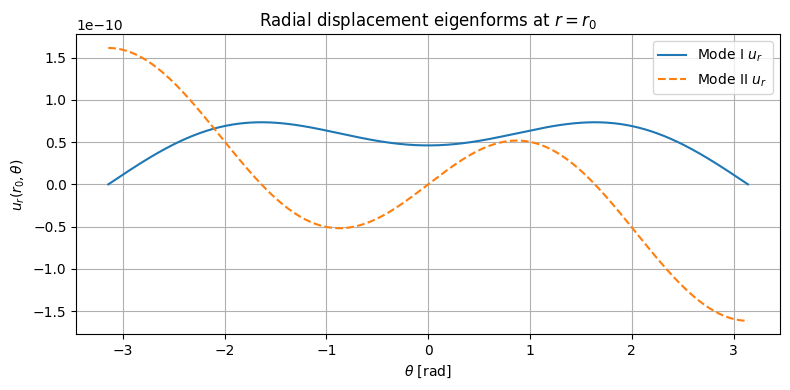

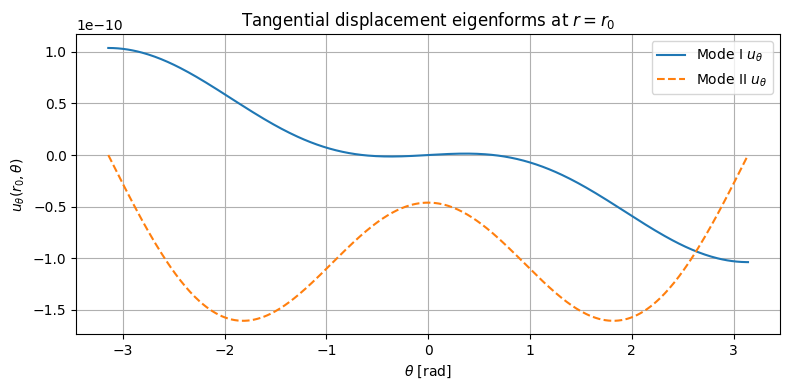

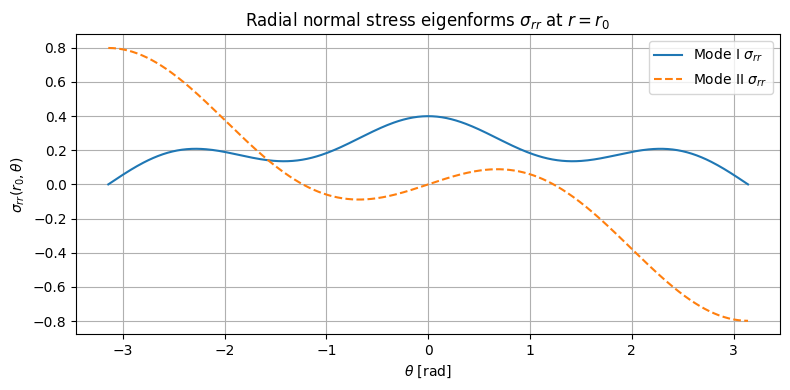

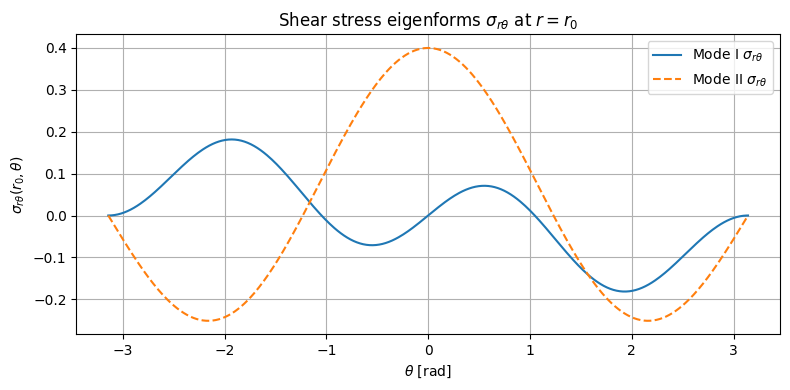

In [8]:
# Plot Mode I vs Mode II radial displacement u_r(theta)
plt.figure(figsize=(8, 4))
plt.plot(theta, u_r_I, label="Mode I $u_r$")
plt.plot(theta, u_r_II, label="Mode II $u_r$", linestyle="--")
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel(r"$u_r(r_0,\theta)$")
plt.title("Radial displacement eigenforms at $r = r_0$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot Mode I vs Mode II tangential displacement u_theta(theta)
plt.figure(figsize=(8, 4))
plt.plot(theta, u_t_I, label="Mode I $u_\\theta$")
plt.plot(theta, u_t_II, label="Mode II $u_\\theta$", linestyle="--")
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel(r"$u_\theta(r_0,\theta)$")
plt.title("Tangential displacement eigenforms at $r = r_0$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot Mode I vs Mode II normal stress sigma_rr(theta)
plt.figure(figsize=(8, 4))
plt.plot(theta, sigma_rr_I, label="Mode I $\\sigma_{rr}$")
plt.plot(theta, sigma_rr_II, label="Mode II $\\sigma_{rr}$", linestyle="--")
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel(r"$\sigma_{rr}(r_0,\theta)$")
plt.title(r"Radial normal stress eigenforms $\sigma_{rr}$ at $r = r_0$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# Plot Mode I vs Mode II shear stress sigma_rtheta(theta)
plt.figure(figsize=(8, 4))
plt.plot(theta, sigma_rt_I, label="Mode I $\\sigma_{r\\theta}$")
plt.plot(theta, sigma_rt_II, label="Mode II $\\sigma_{r\\theta}$", linestyle="--")
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel(r"$\sigma_{r\theta}(r_0,\theta)$")
plt.title(r"Shear stress eigenforms $\sigma_{r\theta}$ at $r = r_0$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Words I had to learn
**Eigenform**

The angular shape of the near-tip field associated with a singular exponent $\lambda$

**Modes**

different axes for the crack to experience stress and strain

**Radical scaling**

the way the fields blow up or vanish as you approach the crack tip e.g. $v(r,\theta) \propto r^{\lambda-1}$
